# KNN Modeling

Imports

In [32]:
# plot graph or chart
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import set_config

set_config(display="text")
# metrics
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [33]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Convert "Revenue" to int (0 or 1)

In [34]:
df["Revenue"] = df["Revenue"].astype(int)


Splitting the Data

In [35]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y
)


Categorical Features

In [37]:
categorical_features = [
	"Month",
	"VisitorType",
	"Weekend"
]


ColumnTransformer

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
	transformers=[
		(
			"cat",
			OneHotEncoder(handle_unknown="ignore"),
			categorical_features
		),
		(
			"num",
			StandardScaler(),
			numerical_features
		)
	]
)


Note: unlike the XGBoost notebook, we explicitly `StandardScaler` the numeric columns here instead of using `remainder="passthrough"`. KNN measures distance between points, so unscaled columns like `PageValues` (range: hundreds) would completely dominate a 0/1 column like `Weekend` if left unscaled. Tree-based models like XGBoost don't care about scale, which is why their notebook could skip this.

Transform

In [39]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


## Training 1 - KNN Classifier (Baseline)

Start settings KNN Classifier (default k=5)

In [40]:
model = KNeighborsClassifier()


In [41]:
model.fit(
	X_train_processed,
	y_train
)


KNeighborsClassifier()

Prediction

In [42]:
y_pred = model.predict(
	X_test_processed
)


Baseline Evaluation

In [43]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))


Accuracy : 0.8730738037307381
Precision: 0.6455696202531646
Recall   : 0.4005235602094241
F1       : 0.49434571890145396


## Finding the Best k (Bias-Variance Tradeoff)

K is the single most important hyperparameter for KNN. A small k follows the training data very closely (risk of overfitting/noise), a large k smooths predictions out too much (risk of underfitting). Instead of guessing, we test a range of k values and plot F1 score against k to see where performance peaks.

In [44]:
k_range = range(1, 31)
f1_scores = []

for k in k_range:
	knn_k = KNeighborsClassifier(n_neighbors=k)
	knn_k.fit(X_train_processed, y_train)
	y_pred_k = knn_k.predict(X_test_processed)
	f1_scores.append(f1_score(y_test, y_pred_k))


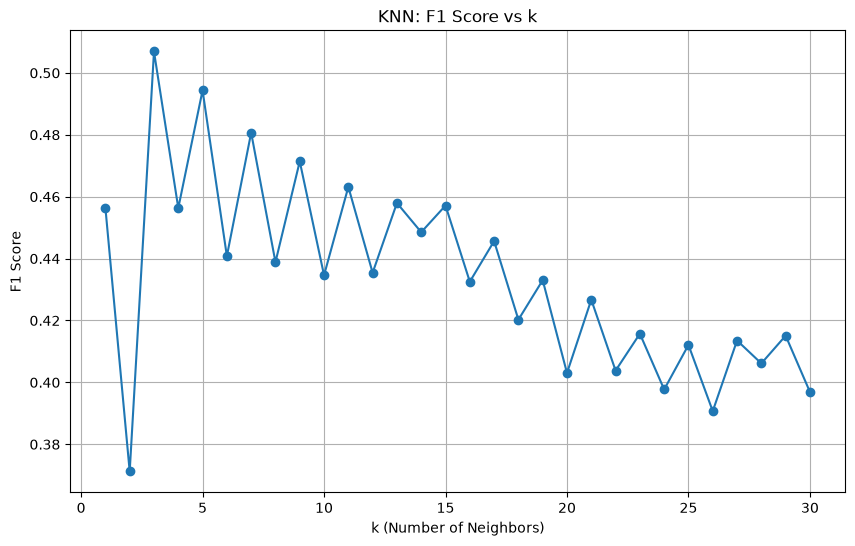

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
	list(k_range),
	f1_scores,
	marker="o"
)

plt.xlabel("k (Number of Neighbors)")
plt.ylabel("F1 Score")
plt.title("KNN: F1 Score vs k")
plt.grid(True)
plt.show()


Read this plot before moving on: find the k where the line peaks. That's your rough target range for GridSearchCV below - it should land near (not necessarily exactly on) the peak you see here, since GridSearchCV also tunes `weights` and `p` jointly with k.

## Training 2 - KNN Classifier (Optimizing Hyperparameters)

New KNN Model - Second round training

In [46]:
knn = KNeighborsClassifier()


Grid of hyperparameters to search:\n- `n_neighbors`: odd values avoid tie votes in binary classification\n- `weights`: \"uniform\" = all neighbors vote equally, \"distance\" = closer neighbors count more\n- `p`: 1 = Manhattan distance, 2 = Euclidean distance

In [47]:
param_grid = {
	"n_neighbors": [3, 5, 7, 9, 11, 15, 21],
	"weights": ["uniform", "distance"],
	"p": [1, 2]
}

grid_search = GridSearchCV(
	estimator=knn,
	param_grid=param_grid,
	scoring="f1",
	cv=5,
	verbose=2,
	n_jobs=-1
)


Fit the model to the training data

In [48]:
grid_search.fit(X_train_processed, y_train)


Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9, 11, 15, 21], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='f1', verbose=2)

Print output

In [49]:
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)


{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
0.5082046456079842
KNeighborsClassifier(n_neighbors=3, weights='distance')


Optimized Model Evaluation

In [50]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_processed)

y_prob = best_model.predict_proba(X_test_processed)[:, 1]


In [51]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print(roc_auc)


0.7571122790445277


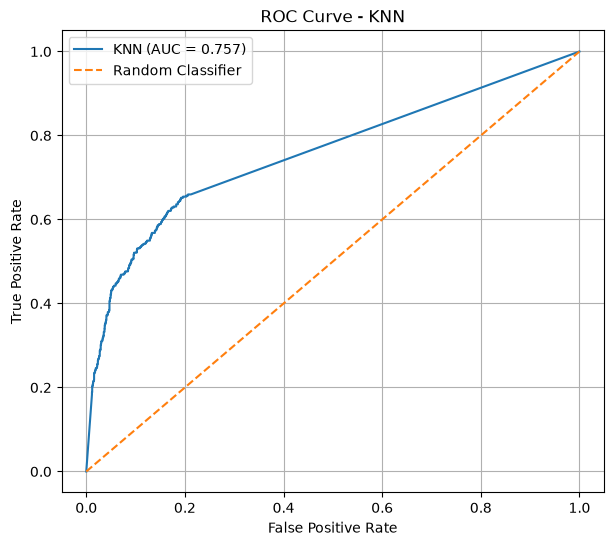

In [52]:
plt.figure(figsize=(7, 6))

plt.plot(
	fpr,
	tpr,
	label=f"KNN (AUC = {roc_auc:.3f})"
)

plt.plot(
	[0, 1],
	[0, 1],
	linestyle="--",
	label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - KNN")

plt.legend()

plt.grid(True)

plt.show()


## Model Evaluation

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


Accuracy : 0.8690186536901865
Precision: 0.6096654275092936
Recall   : 0.4293193717277487
F1       : 0.5038402457757296
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      2084
           1       0.61      0.43      0.50       382

    accuracy                           0.87      2466
   macro avg       0.76      0.69      0.71      2466
weighted avg       0.86      0.87      0.86      2466



Confusion Matrix (CLI version)

In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[1979  105]
 [ 218  164]]


Confusion Matrix (GUI version)

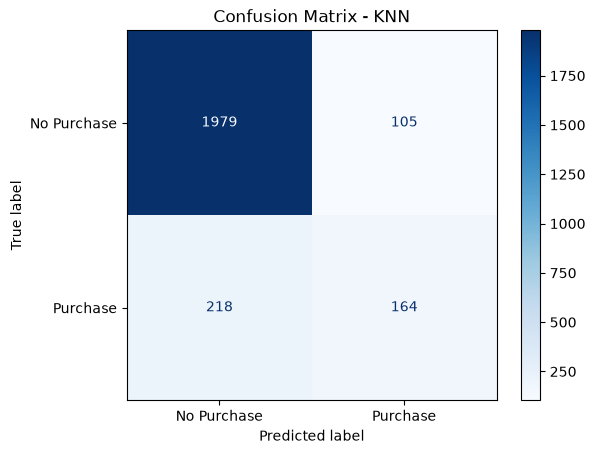

In [55]:
disp = ConfusionMatrixDisplay(
	confusion_matrix=cm,
	display_labels=["No Purchase", "Purchase"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - KNN")
plt.show()


## Baseline vs Tuned Comparison

Unlike XGBoost, KNN has no `.feature_importances_` - it doesn't learn weights per feature, it just measures distance between points. So instead of a feature importance chart, it's more useful here to directly compare the baseline (k=5, default settings) against the tuned model to show the tuning was worth doing.

In [56]:
comparison = pd.DataFrame({
	"Metric": ["Accuracy", "Precision", "Recall", "F1"],
	"Baseline (k=5)": [
		accuracy_score(y_test, model.predict(X_test_processed)),
		precision_score(y_test, model.predict(X_test_processed)),
		recall_score(y_test, model.predict(X_test_processed)),
		f1_score(y_test, model.predict(X_test_processed)),
	],
	"Tuned": [
		accuracy_score(y_test, y_pred),
		precision_score(y_test, y_pred),
		recall_score(y_test, y_pred),
		f1_score(y_test, y_pred),
	]
})

comparison


,Metric,Baseline (k=5),Tuned
0,Accuracy,0.873074,0.869019
1,Precision,0.645570,0.609665
2,Recall,0.400524,0.429319
3,F1,0.494346,0.503840


Checking
before
training
model

In [57]:
import sklearn

print("Scikit-learn:", sklearn.__version__)


Scikit-learn: 1.9.0
